In [1]:
#Load Data Sets

from sklearn.datasets import load_iris;

iris = load_iris();
X = iris['data'];
Y = iris['target'];

n_samples, n_features = X.shape;

print("Number of samples", n_samples);
print("Number of features", n_features);


Number of samples 150
Number of features 4


In [2]:
import numpy as np;

def standardize_data(X):
    #print(np.mean(X, axis=0), np.std(X,  axis = 0))
    print(X[: 10])
    #print(np.mean(X, axis=0))
    #print(X[: 10] - np.mean(X, axis=0))
    #print(np.std(X, axis=0))
    return (X - np.mean(X, axis=0)) / np.std(X, axis = 0);

centered_X = standardize_data(X);

#print(centered_X[: 10])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]


In [3]:
def covariance(A, n):
    return (A.T @ A) / (n - 1);


cov_mat = covariance(centered_X, n_samples - 1);

print(cov_mat);

[[ 1.01351351 -0.11915856  0.88353423  0.82899438]
 [-0.11915856  1.01351351 -0.43422984 -0.37107358]
 [ 0.88353423 -0.43422984  1.01351351  0.97587713]
 [ 0.82899438 -0.37107358  0.97587713  1.01351351]]


In [4]:
from numpy.linalg import eig
eig_vals, eig_vecs = eig(cov_mat);
#print(np.abs(eig_vecs))
print('Eigenvectors \n', eig_vecs)
max_abs_idx = np.argmax(np.abs(eig_vecs), axis=0);
#print(eig_vecs[max_abs_idx, range(eig_vecs.shape[0])]);
signs = np.sign(eig_vecs[max_abs_idx, range(eig_vecs.shape[0])])
#print(signs)
eig_vecs = eig_vecs*signs[np.newaxis,:]
print(signs[np.newaxis,:]);
eig_vecs = eig_vecs.T
print('Eigenvalues \n', eig_vals)
print('Eigenvectors \n', eig_vecs)




Eigenvectors 
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]
[[ 1. -1. -1. -1.]]
Eigenvalues 
 [2.95793698 0.92638223 0.14874008 0.02099477]
Eigenvectors 
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]


In [5]:
# We first make a list of (eigenvalue, eigenvector) tuples
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[i,:]) for i in range(len(eig_vals))]

# Then, we sort the tuples from the highest to the lowest based on eigenvalues magnitude
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# For further usage
eig_vals_sorted = np.array([x[0] for x in eig_pairs])
eig_vecs_sorted = np.array([x[1] for x in eig_pairs])

print(eig_pairs)

[(np.float64(2.9579369762148584), array([ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654])), (np.float64(0.9263822345960179), array([0.37741762, 0.92329566, 0.02449161, 0.06694199])), (np.float64(0.14874007659254915), array([ 0.71956635, -0.24438178, -0.14212637, -0.63427274])), (np.float64(0.020994766650627963), array([-0.26128628,  0.12350962,  0.80144925, -0.52359713]))]


In [6]:
# Select top k eigenvectors
k = 2
W = eig_vecs_sorted[:k, :] # Projection matrix;

X_proj = centered_X.dot(W.T);



Explained variance: [72.96 22.85  3.67  0.52]
Cumulative explained variance: [ 72.96  95.81  99.48 100.  ]


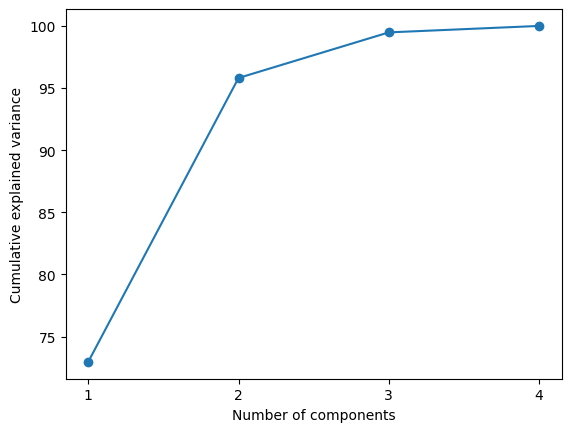

In [7]:
import matplotlib.pyplot as plt

eig_vals_total = sum(eig_vals)
explained_variance = [(i / eig_vals_total)*100 for i in eig_vals_sorted]
explained_variance = np.round(explained_variance, 2)
cum_explained_variance = np.cumsum(explained_variance)

print('Explained variance: {}'.format(explained_variance))
print('Cumulative explained variance: {}'.format(cum_explained_variance))

plt.plot(np.arange(1,n_features+1), cum_explained_variance, '-o')
plt.xticks(np.arange(1,n_features+1))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance');
plt.show()

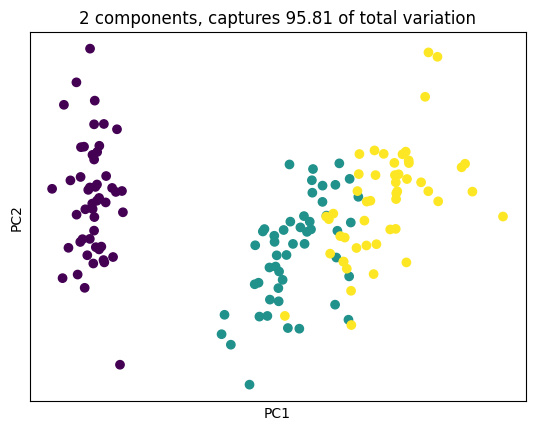

In [8]:
%matplotlib inline

plt.scatter(X_proj[:, 0], X_proj[:, 1], c = Y)
plt.xlabel('PC1'); plt.xticks([])
plt.ylabel('PC2'); plt.yticks([])
plt.title('2 components, captures {} of total variation'.format(cum_explained_variance[1]))
plt.show()


In [9]:
from numpy.linalg import svd

U, Sigma, V_T = svd(cov_mat);

print(eig_vecs_sorted)
print(U.T)
print(Sigma)
print(V_T)

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]
[[-0.52106591  0.26934744 -0.5804131  -0.56485654]
 [-0.37741762 -0.92329566 -0.02449161 -0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [ 0.26128628 -0.12350962 -0.80144925  0.52359713]]
[2.95793698 0.92638223 0.14874008 0.02099477]
[[-0.52106591  0.26934744 -0.5804131  -0.56485654]
 [-0.37741762 -0.92329566 -0.02449161 -0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [ 0.26128628 -0.12350962 -0.80144925  0.52359713]]


In [10]:
k_svd = 2
W_svd = eig_vecs_sorted[:k_svd, :] # Projection matrix;
X_proj_svd = centered_X.dot(W_svd.T);

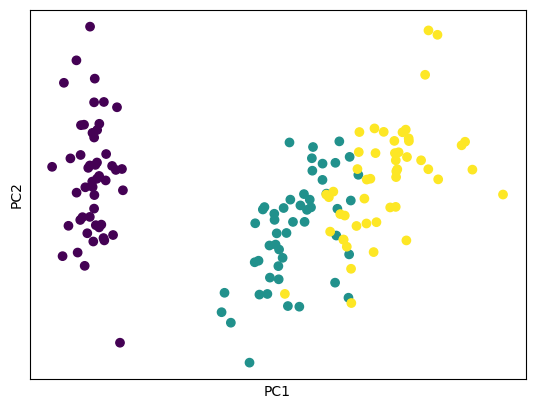

In [11]:
plt.scatter(X_proj_svd[:, 0], X_proj_svd[:, 1], c = Y)
plt.xlabel('PC1'); plt.xticks([])
plt.ylabel('PC2'); plt.yticks([])
plt.show()